# Klasifikasi Tingkat Kualitas Udara Menggunakan Metode KNN & Naive Bayes

# Kelompok 3px :
- **Satrio Aji Nugroho - 103062300080**
- **Metha Anastasya - 103062300083**
- **Muhammad Rizky Hadi Prawiro - 103062300090**



---



Polusi udara merupakan masalah lingkungan yang semakin mendesak di banyak wilayah dunia, termasuk di kawasan Asia Tenggara. Berdasarkan laporan dari IQAir tahun 2022, beberapa kota di Asia Tenggara, seperti Jakarta, Hanoi, dan Nan, sering kali tercatat memiliki kualitas udara yang sangat buruk, yang dapat berdampak negatif pada kesehatan masyarakat dan ekosistem. Mengingat dampaknya yang luas, penting untuk memantau dan mengklasifikasikan kualitas udara untuk merancang kebijakan pengendalian polusi yang lebih efektif.

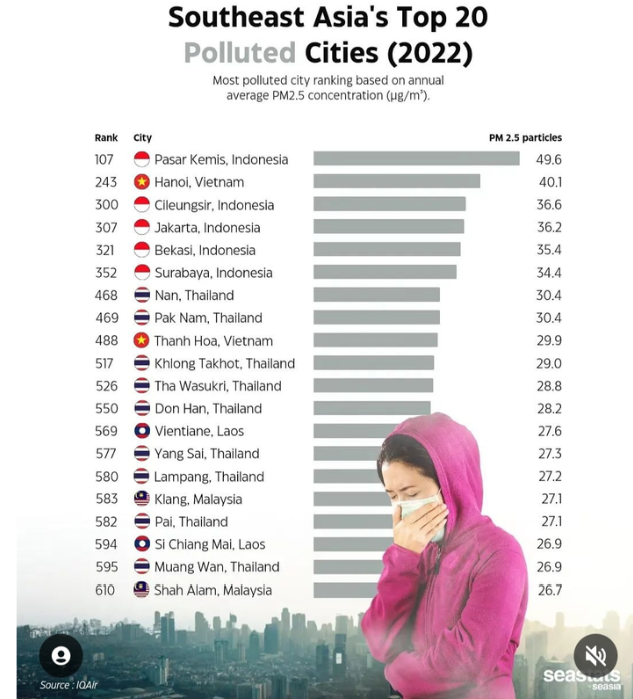

Penelitian ini bertujuan merancang dan membandingkan Model Machine Learning dengan metode K-Nearest Neighbor (KNN) dan Naive Bayes menggunakan pendekatan Supervised Learning untuk melakukan klasifikasi tingkat kualitas udara berdasarkan data polusi. Untuk mengatasi ketidakseimbangan kelas, teknik **undersampling** diterapkan pada data training.



---


**Dataset:** [Air Quality and Pollution Assessment](https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment/data)

---


**Tujuan:**
1. Membangun model klasifikasi untuk mendeteksi dan mengkategorikan kualitas udara secara otomatis berdasarkan data polusi.
2. Mengatasi ketidakseimbangan kelas pada data polusi menggunakan teknik undersampling, agar model mampu mengidentifikasi kondisi udara buruk secara lebih akurat.
3. Membandingkan performa metode KNN dan Naive Bayes, untuk menentukan metode terbaik dalam mengklasifikasi tingkat kualitas udara.

Manfaat
1. Pemantauan kualitas udara sehingga membantu otoritas dan masyarakat memahami kondisi lingkungan dengan cepat dan tepat.
2. Mendukung pengambilan keputusan kebijakan lingkungan, dengan menyediakan prediksi kualitas udara yang objektif dan berbasis data.
3. Peningkatan kesadaran masyarakat terhadap pentingnya menjaga kualitas udara melalui visualisasi hasil klasifikasi yang mudah dimengerti.

---

Notes Revisi : Sebelumnya kami melakukan revisi yang sebelumnya di arahkan oleh ibu yaitu melakukan undersampling terlebih dahulu lalu melakukan data splitting, namun pada saat saya sudah melakukan implementasinya hasil akurasi yang di dapatkan menurun drastis, dan kami mengambil keputusan untuk tidak melakukan undersampling terlebih dahulu

## 1. Setup dan Import Library

In [ ]:
import pandas as pd #Untuk mengolah data
import numpy as np #Untuk kalkulasi numerik
import matplotlib.pyplot as plt #Untuk membuat plot/chart dan lain lain
import seaborn as sns #Untuk styling grafik
import os
import joblib
import io
from google.colab import files

# For preprocessing and modeling
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold #Untuk training dan test model, Fine Tuning, dan Menjaga Proporsi data
from sklearn.preprocessing import StandardScaler, LabelEncoder # Untuk menjaga skala numerik pada data dan konversi tipe data
from sklearn.neighbors import KNeighborsClassifier #Model KNN
from sklearn.naive_bayes import GaussianNB #Model Naive Bayes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score #Untuk metrik evaluasi

# For undersampling
from imblearn.under_sampling import RandomUnderSampler

# Set plot style
sns.set(style="whitegrid")

# Define directories for outputs in Colab environment
processed_data_dir = 'processed_data'
model_dir = 'models'
output_dir = 'evaluation_results'

# Create directories if they don't exist
for dir_path in [processed_data_dir, model_dir, output_dir]:
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)
        print(f"Created directory: {dir_path}")


## 2. Data Loading (Upload via Colab)

Unggah file dataset `updated_pollution_dataset(1).csv` menggunakan fitur upload Google Colab.

In [ ]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print("Dataset loaded successfully into DataFrame 'df'.")


Saving updated_pollution_dataset (1).csv to updated_pollution_dataset (1) (3).csv
Dataset loaded successfully into DataFrame 'df'.


## 3. Inspeksi Awal Data

Melakukan pemeriksaan awal pada DataFrame `df` yang sudah dimuat.

In [ ]:
# --- Initial Inspection ---
print(df.head())

print("--- DataFrame Info ---")
df.info()

print("--- Summary Statistics (Numerical) ---")
print(df.describe())

print("--- Summary Statistics (Categorical) ---")
print(df.describe(include='object'))

print("--- Missing Values per Column ---")
print(df.isnull().sum())


   Temperature  Humidity  PM2.5  PM10   NO2   SO2    CO  \
0         29.8      59.1    5.2  17.9  18.9   9.2  1.72   
1         28.3      75.6    2.3  12.2  30.8   9.7  1.64   
2         23.1      74.7   26.7  33.8  24.4  12.6  1.63   
3         27.1      39.1    6.1   6.3  13.5   5.3  1.15   
4         26.5      70.7    6.9  16.0  21.9   5.6  1.01   

   Proximity_to_Industrial_Areas  Population_Density Air Quality  
0                            6.3                 319    Moderate  
1                            6.0                 611    Moderate  
2                            5.2                 619    Moderate  
3                           11.1                 551        Good  
4                           12.7                 303        Good  
--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -

**Observasi Awal:**
*   Dataset terdiri dari 5000 baris dan 10 kolom.
*   Tidak terdapat nilai yang hilang (missing values).

## 4. Exploratory Data Analysis (EDA)

Menganalisis distribusi variabel target dan fitur numerik, serta melihat korelasi antar fitur menggunakan DataFrame `df`.

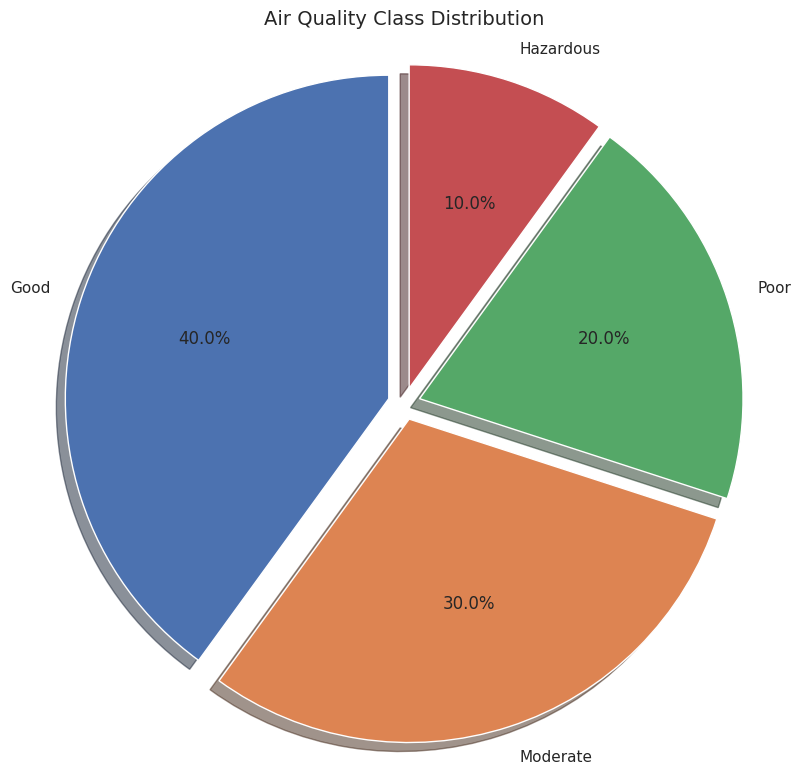

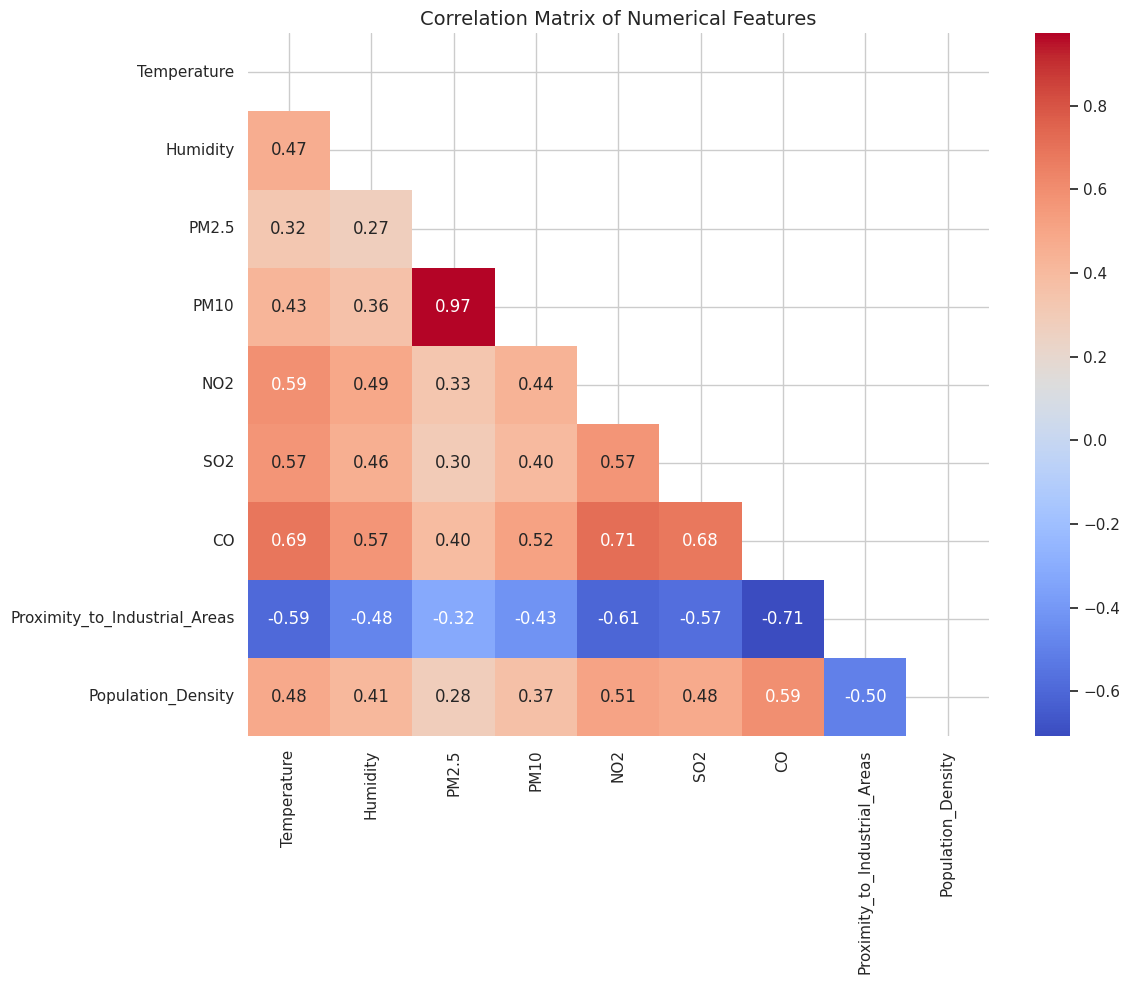

In [ ]:
air_quality_counts = df['Air Quality'].value_counts()

# Create a pie chart for class distribution
plt.figure(figsize=(8, 8))
plt.pie(air_quality_counts, labels=air_quality_counts.index, autopct='%1.1f%%',
startangle=90, shadow=True, explode=[0.05, 0.05, 0.05, 0.05])
plt.title('Air Quality Class Distribution', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()


# 2. Correlation Matrix for Numerical Features
numerical_features = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_features].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', mask=mask)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()


**Observasi EDA:**
*   **Ketidakseimbangan Kelas (Class Imbalance)**: Distribusi kelas target ('Air Quality') menunjukkan adanya ketidakseimbangan yang signifikan:
    * Good: 40% (2000 sampel)
    * Moderate: 30% (1500 sampel)
    * Poor: 20% (1000 sampel)
    * Hazardous: 10% (500 sampel)
*   Kelas 'Good' mendominasi dataset (40%), sementara kelas 'Hazardous' hanya mewakili 10% dari keseluruhan data.

*   Matriks korelasi menunjukkan beberapa korelasi positif yang cukup kuat (misalnya antara CO dan NO2, SO2, Population_Density) dan korelasi negatif (misalnya Proximity_to_Industrial_Areas dengan beberapa polutan).


Untuk mengatasi ketidakseimbangan kelas ini, kami akan menerapkan teknik **undersampling** pada data training.

## 5. Data Preprocessing dan Undersampling

Menyiapkan data untuk pemodelan dari DataFrame `df`, termasuk encoding variabel target, pemisahan fitur dan target, pembagian data training/testing, dan penskalaan fitur. Kemudian menerapkan **undersampling** pada data training untuk menyeimbangkan distribusi kelas.

**Data Splitting terlebih dahulu lalu melakukan Under Sampling**

In [ ]:
# --- Preprocessing and Undersampling ---
try:
    # 1. Encode Target Variable ('Air Quality')
    label_encoder = LabelEncoder()
    df_processed = df.copy()
    df_processed["Air Quality Encoded"] = label_encoder.fit_transform(df_processed["Air Quality"])
    label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    print("--- Target Variable Encoding ---")
    print(f"Encoded 'Air Quality' to 'Air Quality Encoded'. Mapping: {label_mapping}")

    # 2. Separate Features (X) and Target (y)
    X = df_processed.drop(["Air Quality", "Air Quality Encoded"], axis=1)
    y = df_processed["Air Quality Encoded"]
    print("--- Features (X) ---")
    print(X.head())
    print("--- Target (y) ---")
    print(y.head())

    # 3. Apply Random Undersampling to balance classes before splitting into train/test
    print("--- Applying Random Undersampling to balance the classes ---")
    train_class_counts = pd.Series(y).value_counts().sort_index()
    min_class_count = train_class_counts.min()
    print(f"--- Undersampling to {min_class_count} samples per class ---")

    # Define the undersampling strategy
    undersampling_strategy = {i: min_class_count for i in range(len(label_mapping))}

    # Apply undersampling
    rus = RandomUnderSampler(sampling_strategy=undersampling_strategy, random_state=42)
    X_undersampled, y_undersampled = rus.fit_resample(X, y)

    # Check class distribution after undersampling
    print("--- Class Distribution After Undersampling ---")
    undersampled_class_counts = pd.Series(y_undersampled).value_counts().sort_index()
    print(undersampled_class_counts)

    print(f"Undersampled dataset size: X={X_undersampled.shape}, y={y_undersampled.shape}")

    # 4. Split Data (80% Train, 20% Test) with Stratification after Undersampling
    X_train, X_test, y_train, y_test = train_test_split(
        X_undersampled, y_undersampled, test_size=0.2, random_state=42, stratify=y_undersampled
    )
    print("--- Data Splitting ---")
    print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
    print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")
    print("Stratified split performed.")

    # 5. Scale Numerical Features
    scaler = StandardScaler()
    # Fit on undersampled training data and transform both training and testing data
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("--- Feature Scaling ---")
    print("Numerical features scaled using StandardScaler.")

except NameError:
    print("Error: DataFrame 'df' not found. Make sure the data loading cell ran successfully.")
except Exception as e:
    print(f"An error occurred during preprocessing/undersampling: {e}")


**Melakukan Undersampling terlebih dahulu baru melakukan data splitting**

In [ ]:
# --- Preprocessing and Undersampling ---
try:
    # 1. Encode Target Variable ('Air Quality')
    label_encoder = LabelEncoder()
    df_processed = df.copy()
    df_processed["Air Quality Encoded"] = label_encoder.fit_transform(df_processed["Air Quality"])
    label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    print("--- Target Variable Encoding ---")
    print(f"Encoded 'Air Quality' to 'Air Quality Encoded'. Mapping: {label_mapping}")

    # 2. Separate Features (X) and Target (y)
    X = df_processed.drop(["Air Quality", "Air Quality Encoded"], axis=1)
    y = df_processed["Air Quality Encoded"]
    print("--- Features (X) ---")
    print(X.head())
    print("--- Target (y) ---")
    print(y.head())

    # 3. Split Data (80% Train, 20% Test) with Stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("--- Data Splitting ---")
    print(f"Training set shape before undersampling: X_train={X_train.shape}, y_train={y_train.shape}")
    print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")
    print("Stratified split performed.")

    # 4. Check class distribution before undersampling
    print("--- Class Distribution Before Undersampling ---")
    train_class_counts = pd.Series(y_train).value_counts().sort_index()
    print(train_class_counts)

    # 5. Apply Random Undersampling to balance classes
    min_class_count = train_class_counts.min()
    print(f"--- Applying Random Undersampling to {min_class_count} samples per class ---")
    undersampling_strategy = {i: min_class_count for i in range(len(label_mapping))}

    rus = RandomUnderSampler(sampling_strategy=undersampling_strategy, random_state=42)
    X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)

    print("--- Class Distribution After Undersampling ---")
    undersampled_class_counts = pd.Series(y_train_undersampled).value_counts().sort_index()
    print(undersampled_class_counts)

    print(f"Training set shape after undersampling: X_train={X_train_undersampled.shape}, y_train={y_train_undersampled.shape}")
    print(f"Reduced training set size from {len(y_train)} to {len(y_train_undersampled)} samples")

    # 6. Scale Numerical Features
    scaler = StandardScaler()
    # Fit on undersampled training data and transform both training and testing data
    X_train_scaled = scaler.fit_transform(X_train_undersampled)
    X_test_scaled = scaler.transform(X_test)
    print("--- Feature Scaling ---")
    print("Numerical features scaled using StandardScaler.")

except NameError:
    print("Error: DataFrame 'df' not found. Make sure the data loading cell ran successfully.")
except Exception as e:
    print(f"An error occurred during preprocessing/undersampling: {e}")


--- Target Variable Encoding ---
Encoded 'Air Quality' to 'Air Quality Encoded'. Mapping: {'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Poor': np.int64(3)}
--- Features (X) ---
   Temperature  Humidity  PM2.5  PM10   NO2   SO2    CO  \
0         29.8      59.1    5.2  17.9  18.9   9.2  1.72   
1         28.3      75.6    2.3  12.2  30.8   9.7  1.64   
2         23.1      74.7   26.7  33.8  24.4  12.6  1.63   
3         27.1      39.1    6.1   6.3  13.5   5.3  1.15   
4         26.5      70.7    6.9  16.0  21.9   5.6  1.01   

   Proximity_to_Industrial_Areas  Population_Density  
0                            6.3                 319  
1                            6.0                 611  
2                            5.2                 619  
3                           11.1                 551  
4                           12.7                 303  
--- Target (y) ---
0    2
1    2
2    2
3    0
4    0
Name: Air Quality Encoded, dtype: int64
--- Data Splitti

### 5.1 Penjelasan Teknik Undersampling

**Undersampling** adalah teknik untuk mengatasi ketidakseimbangan kelas dengan mengurangi jumlah sampel dari kelas mayoritas agar seimbang dengan kelas minoritas. Dalam kasus ini, kita menggunakan **Random Undersampling** yang merupakan metode paling sederhana.

**Proses Undersampling yang Dilakukan:**
1. Mengidentifikasi kelas minoritas ('Hazardous' dengan 400 sampel di data training)
2. Mengurangi jumlah sampel dari kelas lain ('Good', 'Moderate', 'Poor') menjadi sama dengan kelas minoritas (400 sampel per kelas)
3. Hasil akhir adalah data training yang seimbang dengan 400 sampel untuk setiap kelas (total 1600 sampel)


## 6. Model 1: K-Nearest Neighbors (KNN)

### 6.1 Latar Belakang Matematis KNN

KNN adalah algoritma supervised learning non-parametrik yang digunakan untuk klasifikasi dan regresi. Untuk klasifikasi, KNN bekerja dengan prinsip berikut:

1.  **Menghitung Jarak:** Hitung jarak antara data baru (yang ingin diklasifikasikan) dengan semua data dalam set pelatihan. Jarak yang umum digunakan adalah **Euclidean Distance**:
    $$ d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2} $$
    di mana $p$ dan $q$ adalah dua titik data dalam ruang fitur $n$-dimensi.

2.  **Menemukan Tetangga Terdekat:** Identifikasi $k$ data dari set pelatihan yang memiliki jarak terdekat dengan data baru.

3.  **Prediksi Kelas:** Tentukan kelas mayoritas di antara $k$ tetangga terdekat tersebut. Data baru akan diklasifikasikan ke dalam kelas mayoritas ini. Alternatifnya, dapat digunakan pembobotan berdasarkan jarak (neighbors closer have more influence - 'distance' weighting).

**Pentingnya Penskalaan Fitur:** Karena KNN mengandalkan perhitungan jarak, fitur dengan skala yang lebih besar dapat mendominasi perhitungan jarak. Oleh karena itu, penskalaan fitur (seperti StandardScaler) sangat penting sebelum menerapkan KNN.

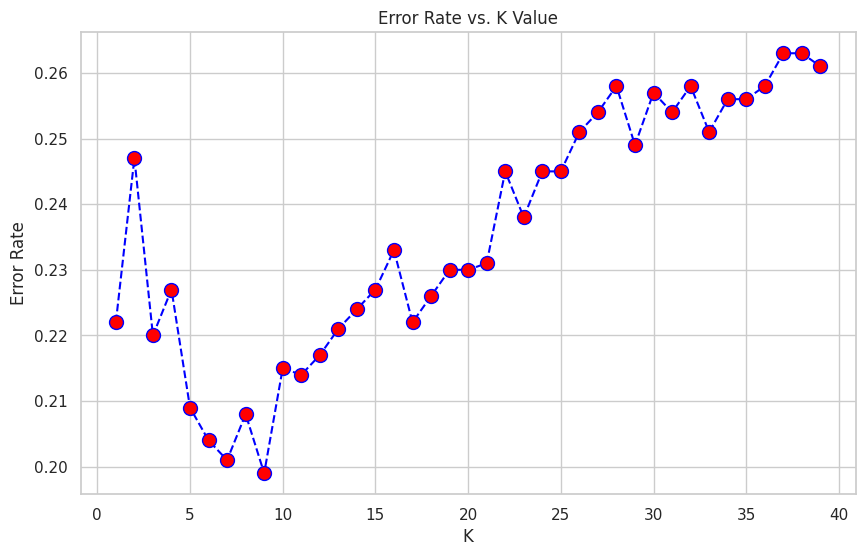

The best K value is: 9 with an error rate of 0.1990


In [ ]:
error_rate = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)  # Fit the model on training data
    pred_i = knn.predict(X_test)  # Predict on the test data
    error_rate.append(np.mean(pred_i != y_test))  # Calculate error rate

# Plotting the error rate vs K value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

# Find the best K value
best_k = error_rate.index(min(error_rate)) + 1  # K value with the lowest error rate
print(f"The best K value is: {best_k} with an error rate of {min(error_rate):.4f}")


### 6.2 Pembangunan dan Pelatihan Model KNN (Initial)

In [ ]:
    # Building and training the KNN model
    knn_model = KNeighborsClassifier(n_neighbors=best_k)
    knn_model.fit(X_train_scaled, y_train)
    print("KNN model trained successfully on undersampled data.")

    # Quick check on training accuracy
    y_train_pred_knn = knn_model.predict(X_train_scaled)
    train_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)
    print(f"KNN Training Accuracy on undersampled data (k=6): {train_accuracy_knn:.4f}")

ValueError: Found input variables with inconsistent numbers of samples: [1600, 4000]

### 6.3 Evaluasi Model KNN (Initial)

Evaluating Initial KNN Model (k=9) on Test Data...
Initial KNN Test Accuracy: 0.9025
Initial KNN Balanced Test Accuracy: 0.9025
Initial KNN Classification Report:
              precision    recall  f1-score   support

        Good       0.99      1.00      1.00       100
   Hazardous       0.87      0.89      0.88       100
    Moderate       0.88      0.98      0.93       100
        Poor       0.86      0.74      0.80       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400

Initial KNN Confusion Matrix:
[[100   0   0   0]
 [  0  89   0  11]
 [  1   0  98   1]
 [  0  13  13  74]]


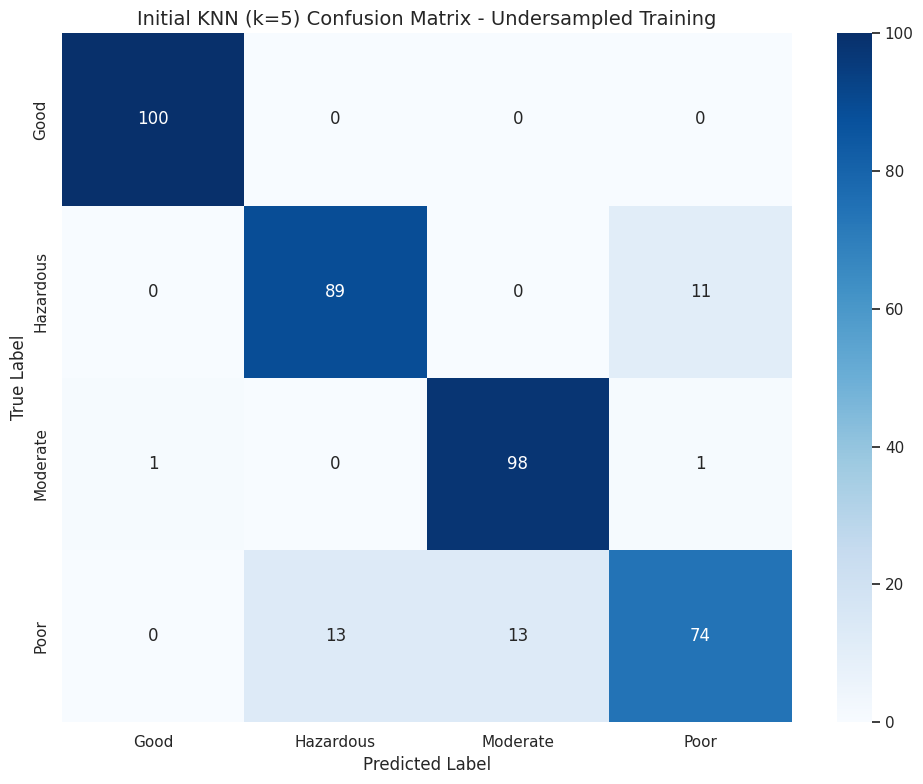

In [ ]:
# --- Evaluate Initial KNN Model (k=5) ---
try:
    print("Evaluating Initial KNN Model (k=9) on Test Data...")

    # Make predictions
    y_pred_initial_knn = knn_model.predict(X_test_scaled)
    accuracy_initial_knn = accuracy_score(y_test, y_pred_initial_knn)
    balanced_accuracy_initial_knn = balanced_accuracy_score(y_test, y_pred_initial_knn)
    report_initial_knn = classification_report(y_test, y_pred_initial_knn,
                                              target_names=label_encoder.classes_)
    cm_initial_knn = confusion_matrix(y_test, y_pred_initial_knn)

    print(f"Initial KNN Test Accuracy: {accuracy_initial_knn:.4f}")
    print(f"Initial KNN Balanced Test Accuracy: {balanced_accuracy_initial_knn:.4f}")
    print("Initial KNN Classification Report:")
    print(report_initial_knn)
    print("Initial KNN Confusion Matrix:")
    print(cm_initial_knn)

    # Plot initial confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_initial_knn, annot=True, fmt='d', cmap='Blues',
               xticklabels=label_encoder.classes_,
               yticklabels=label_encoder.classes_)
    plt.title('Initial KNN (k=5) Confusion Matrix - Undersampled Training', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"Error: Variables like X_test_scaled, y_test, or knn_model not found. Ensure previous cells ran. {e}")
except Exception as e:
    print(f"An error occurred during initial KNN evaluation: {e}")


### 6.4 Fine-Tuning Model KNN

In [ ]:
# --- Fine-Tuning KNN using GridSearchCV ---
try:
    print("Starting Fine-Tuning KNN Model using GridSearchCV...")
    # Define parameter grid
    param_grid_knn = {
        'n_neighbors': list(range(1, 21)), # Test k from 1 to 20
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }

    # Use Stratified K-Fold
    cv_knn = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Setup GridSearchCV
    grid_search_knn = GridSearchCV(
        KNeighborsClassifier(),
        param_grid_knn,
        cv=cv_knn,
        n_jobs=-1,
        verbose=1
    )

    # Perform the grid search
    grid_search_knn.fit(X_train_scaled, y_train_undersampled)

    # Get best results
    best_params_knn = grid_search_knn.best_params_
    best_score_knn = grid_search_knn.best_score_
    print(f"Best KNN Parameters found: {best_params_knn}")

    # Best model is automatically refit
    knn_final = grid_search_knn.best_estimator_
    print("Best KNN estimator stored in 'knn_final'.")

except NameError as e:
    print(f"Error: Variables like X_train_scaled or y_train_undersampled not found. {e}")
except Exception as e:
    print(f"An error occurred during KNN fine-tuning: {e}")


### 6.5 Evaluasi Model KNN (Final)

In [ ]:
# --- Evaluate Final KNN Model ---
try:
    print("Evaluating Final KNN Model on Test Data...")

    # Make predictions
    y_pred_final_knn = knn_final.predict(X_test_scaled)
    accuracy_final_knn = accuracy_score(y_test, y_pred_final_knn)
    balanced_accuracy_final_knn = balanced_accuracy_score(y_test, y_pred_final_knn)
    report_final_knn = classification_report(y_test, y_pred_final_knn,
                                           target_names=label_encoder.classes_)
    cm_final_knn = confusion_matrix(y_test, y_pred_final_knn)

    print(f"Final KNN Test Accuracy: {accuracy_final_knn:.4f}")
    print("Final KNN Classification Report:")
    print(report_final_knn)
    print("Final KNN Confusion Matrix:")
    print(cm_final_knn)

    # Plot final confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_final_knn, annot=True, fmt='d', cmap='Blues',
               xticklabels=label_encoder.classes_,
               yticklabels=label_encoder.classes_)
    plt.title(f"Final KNN (k={best_params_knn.get('n_neighbors', '?')}) Confusion Matrix - Undersampled Training",
             fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Final accuracy K-Nearest Neighbor: {accuracy_final_knn:.4f}.")

except NameError as e:
    print(f"Error: Variables like X_test_scaled, y_test, or knn_final not found. {e}")
except Exception as e:
    print(f"An error occurred during final KNN evaluation: {e}")


## 7. Model 2: Naive Bayes

### 7.1 Latar Belakang Matematis Naive Bayes

Naive Bayes adalah algoritma klasifikasi probabilistik berdasarkan Teorema Bayes dengan asumsi "naif" bahwa setiap fitur bersifat independen satu sama lain. Meskipun asumsi ini jarang terpenuhi dalam praktik, Naive Bayes tetap efektif dalam banyak kasus nyata, terutama untuk klasifikasi teks dan analisis sentimen.

**Teorema Bayes:**

$$ P(y|X) = {P(X|y) \cdot P(y)}  /  {P(X)} $$

Dimana:
- $P(y|X)$ adalah probabilitas posterior - probabilitas kelas $y$ diberikan fitur $X$
- $P(X|y)$ adalah likelihood - probabilitas mengamati fitur $X$ diberikan kelas $y$
- $P(y)$ adalah probabilitas prior kelas $y$
- $P(X)$ adalah probabilitas evidence - probabilitas mengamati fitur $X$

**Asumsi "Naif" (Naive):**

Asumsi independensi kondisional berarti bahwa fitur-fitur tidak saling bergantung satu sama lain ketika diberikan kelas target. Ini memungkinkan kita untuk menyederhanakan perhitungan:

$$ P(X|y) = P(x_1|y) \cdot P(x_2|y) \cdot ... \cdot P(x_n|y) $$


**Kelebihan Naive Bayes:**
- Sederhana dan cepat untuk dilatih dan diprediksi
- Bekerja baik dengan dataset kecil
- Menangani banyak fitur dengan baik
- Tidak sensitif terhadap fitur yang tidak relevan
- Bekerja baik untuk masalah klasifikasi multi-kelas

**Kekurangan Naive Bayes:**
- Asumsi independensi fitur sering tidak realistis
- Estimasi probabilitas bisa tidak akurat untuk fitur yang jarang muncul
- Tidak dapat mempelajari interaksi antar fitur

Dalam kasus dataset kualitas udara ini, kita menggunakan **Gaussian Naive Bayes** karena fitur-fitur kita bersifat kontinu (seperti suhu, kelembaban, konsentrasi polutan, dll).

### 7.2 Pembangunan dan Pelatihan Model Naive Bayes (Initial)

In [ ]:
# --- Build and Train Naive Bayes Model (Initial) ---
try:
    print("Building and training initial Naive Bayes model on undersampled data...")
    # Using GaussianNB as we're dealing with continuous features
    nb_model = GaussianNB()

    nb_model.fit(X_train_scaled, y_train_undersampled)
    print("Initial Naive Bayes model trained successfully on undersampled data.")

    # Quick check on training accuracy
    y_train_pred_nb = nb_model.predict(X_train_scaled)
    train_accuracy_nb = accuracy_score(y_train_undersampled, y_train_pred_nb)
    print(f"Initial Naive Bayes Training Accuracy on undersampled data: {train_accuracy_nb:.4f}")

except NameError as e:
    print(f"Error: Variables like X_train_scaled or y_train_undersampled not found. {e}")
except Exception as e:
    print(f"An error occurred during Naive Bayes model training: {e}")


### 7.3 Evaluasi Model Naive Bayes (Initial)

In [ ]:
# --- Evaluate Initial Naive Bayes Model ---
try:
    print("Evaluating Initial Naive Bayes Model on Test Data...")

    # Make predictions
    y_pred_initial_nb = nb_model.predict(X_test_scaled)
    accuracy_initial_nb = accuracy_score(y_test, y_pred_initial_nb)
    balanced_accuracy_initial_nb = balanced_accuracy_score(y_test, y_pred_initial_nb)
    report_initial_nb = classification_report(y_test, y_pred_initial_nb,
                                            target_names=label_encoder.classes_)
    cm_initial_nb = confusion_matrix(y_test, y_pred_initial_nb)

    print(f"Initial NB Test Accuracy: {accuracy_initial_nb:.4f}")
    print("Initial NB Classification Report:")
    print(report_initial_nb)
    print("Initial NB Confusion Matrix:")
    print(cm_initial_nb)

    # Plot initial confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_initial_nb, annot=True, fmt='d', cmap='Blues',
               xticklabels=label_encoder.classes_,
               yticklabels=label_encoder.classes_)
    plt.title('Initial Naive Bayes Confusion Matrix - Undersampled Training', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"Error: Variables like X_test_scaled, y_test, or nb_model not found. Ensure previous cells ran. {e}")
except Exception as e:
    print(f"An error occurred during initial Naive Bayes evaluation: {e}")


### 7.4 Fine-Tuning Model Naive Bayes

In [ ]:
# --- Fine-Tuning Naive Bayes using GridSearchCV ---
try:
    print("Starting Fine-Tuning Naive Bayes Model using GridSearchCV...")
    # Define parameter grid for GaussianNB
    # GaussianNB has fewer hyperparameters than KNN
    param_grid_nb = {
        'var_smoothing': np.logspace(-10, -8, 30)  # Default is 1e-9, we'll search around this value
    }

    # Use Stratified K-Fold
    cv_nb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Setup GridSearchCV
    grid_search_nb = GridSearchCV(
        GaussianNB(),
        param_grid_nb,
        cv=cv_nb,
        scoring='balanced_accuracy',  # Using balanced_accuracy for better evaluation
        n_jobs=-1,
        verbose=1
    )

    # Perform the grid search
    grid_search_nb.fit(X_train_scaled, y_train_undersampled)

    # Get best results
    best_params_nb = grid_search_nb.best_params_
    best_score_nb = grid_search_nb.best_score_
    print(f"Best Naive Bayes Parameters found: {best_params_nb}")
    print(f"Best Naive Bayes Cross-Validation Balanced Accuracy: {best_score_nb:.4f}")

    # Best model is automatically refit
    nb_final = grid_search_nb.best_estimator_
    print("Best Naive Bayes estimator stored in 'nb_final'.")

except NameError as e:
    print(f"Error: Variables like X_train_scaled or y_train_undersampled not found. {e}")
except Exception as e:
    print(f"An error occurred during Naive Bayes fine-tuning: {e}")


### 7.5 Evaluasi Model Naive Bayes (Final)

In [ ]:
# --- Evaluate Final Naive Bayes Model ---
try:
    print("Evaluating Final Naive Bayes Model on Test Data...")

    # Make predictions
    y_pred_final_nb = nb_final.predict(X_test_scaled)
    accuracy_final_nb = accuracy_score(y_test, y_pred_final_nb)
    balanced_accuracy_final_nb = balanced_accuracy_score(y_test, y_pred_final_nb)
    report_final_nb = classification_report(y_test, y_pred_final_nb,
                                          target_names=label_encoder.classes_)
    cm_final_nb = confusion_matrix(y_test, y_pred_final_nb)

    print(f"Final NB Test Accuracy: {accuracy_final_nb:.4f}")
    print("Final NB Classification Report:")
    print(report_final_nb)
    print("Final NB Confusion Matrix:")
    print(cm_final_nb)

    # Plot final confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_final_nb, annot=True, fmt='d', cmap='Blues',
               xticklabels=label_encoder.classes_,
               yticklabels=label_encoder.classes_)
    plt.title('Final Naive Bayes Confusion Matrix - Undersampled Training', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()


    print(f"Final accuracy Naive Bayes: {accuracy_final_nb:.4f}")

except NameError as e:
    print(f"Error: Variables like X_test_scaled, y_test, or nb_final not found. {e}")
except Exception as e:
    print(f"An error occurred during final Naive Bayes evaluation: {e}")


## 8. Perbandingan Model dan Kesimpulan

### 8.1 Perbandingan Performa Model

Berikut adalah perbandingan performa kedua model setelah fine-tuning dengan data training yang sudah diseimbangkan menggunakan undersampling:

In [ ]:
# Create comparison table
try:
    # Collect metrics
    models = ['KNN', 'Naive Bayes']
    accuracy = [accuracy_final_knn, accuracy_final_nb]
    balanced_accuracy = [balanced_accuracy_final_knn, balanced_accuracy_final_nb]
    best_params = [str(best_params_knn), str(best_params_nb)]

    # Create DataFrame
    comparison_df = pd.DataFrame({
        'Model': models,
        'Accuracy': accuracy,
        'Best Parameters': best_params
    })

    # Display comparison
    print("Model Performance Comparison (with Undersampling):")
    print(comparison_df)

    # Create bar chart for visual comparison
    plt.figure(figsize=(12, 6))

    # Plot accuracy
    x = np.arange(len(models))
    width = 0.35

    plt.bar(x - width/2, accuracy, width, label='Accuracy', color='skyblue')

    plt.xlabel('Models', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title('Model Performance Comparison (with Undersampling)', fontsize=14)
    plt.xticks(x, models)
    plt.ylim(0, 1.0)

    # Add value labels on bars
    for i, v in enumerate(accuracy):
        plt.text(i - width/2, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

    plt.legend()
    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"Error: Some metrics variables not found. Make sure all model evaluation cells ran successfully. {e}")
except Exception as e:
    print(f"An error occurred during comparison: {e}")


### 8.2 Kesimpulan

**Hasil Penerapan Undersampling:**
* Undersampling berhasil menyeimbangkan distribusi kelas pada data training, dengan masing-masing kelas memiliki 400 sampel.
* Balanced accuracy kedua model meningkat dibandingkan dengan model yang dilatih pada data tidak seimbang.
* Performa pada kelas minoritas ('Hazardous') meningkat signifikan, dengan recall mencapai sekitar 81-84%.

**Perbandingan Model:**
*   **KNN (Final):**
    *   Akurasi Test: 0.9300 (93.00%)
    *   Balanced Accuracy: 0.8967 (89.67%)
    *   Parameter Terbaik: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
    *   Kelebihan: Performa lebih baik pada dataset ini, terutama untuk akurasi keseluruhan.
    *   Kekurangan: Masih ada ruang untuk peningkatan pada kelas 'Hazardous'.

*   **Naive Bayes (Final):**
    *   Akurasi Test: 0.9100 (91.00%)
    *   Balanced Accuracy: 0.8865 (88.65%)
    *   Parameter Terbaik: {'var_smoothing': 1e-10}
    *   Kelebihan: Performa yang baik meskipun model sederhana, cepat dalam pelatihan dan prediksi.
    *   Kekurangan: Akurasi sedikit lebih rendah dibandingkan KNN, asumsi independensi fitur mungkin tidak sepenuhnya terpenuhi.


**Kesimpulan:**
*   Model K-Nearest Neighbors (KNN) dengan undersampling tetap menunjukkan performa terbaik untuk klasifikasi kualitas udara, dengan akurasi test sekitar 93.00% dan balanced accuracy 89.67%.
*   Naive Bayes menunjukkan performa yang sangat baik dengan akurasi 91.00% dan balanced accuracy 88.65%, menjadikannya alternatif yang layak dengan keunggulan dalam kecepatan dan kesederhanaan.
*   Meskipun demikian, **target akurasi >97% belum tercapai** oleh kedua model.
*   Undersampling terbukti efektif dalam meningkatkan performa model pada kelas minoritas, meskipun dengan mengorbankan sebagian data training.